# Proyek Analisis Data: Analisis Kualitas Udara Beijing
- **Nama:** Yahya Putra Pradana
- **Email:** yahya.putra76@gmail.com
- **ID Dicoding:** yahyaputra19

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

**Pertanyaan 1:**
> Pada bulan apa rata-rata konsentrasi PM2.5 dan PM10 tertinggi terjadi, dan seberapa besar persentase jam pengukuran yang melampaui standar tahunan WHO (PM2.5: 5 μg/m³; PM10: 15 μg/m³) di 12 stasiun pemantauan Beijing selama periode Maret 2013 – Februari 2017?

| SMART | Penjelasan |
|-------|-----------|
| **S** – Specific | Fokus pada dua polutan partikulat (PM2.5, PM10) di 12 stasiun spesifik di Beijing |
| **M** – Measurable | Dapat diukur dengan rata-rata bulanan (μg/m³) dan persentase jam melampaui WHO |
| **A** – Action-oriented | Mengidentifikasi bulan kritis untuk intervensi kebijakan pengendalian polusi musiman |
| **R** – Relevant | PM2.5 dan PM10 adalah indikator utama kualitas udara yang berdampak langsung pada kesehatan masyarakat |
| **T** – Time-bound | Dibatasi pada periode data tersedia: Maret 2013 – Februari 2017 |

---

**Pertanyaan 2:**
> Bagaimana pengaruh suhu udara (TEMP) dan kecepatan angin (WSPM) terhadap konsentrasi PM2.5, dan pada kondisi meteorologi apa konsentrasi PM2.5 paling sering melebihi ambang batas berbahaya (>75 μg/m³) di 12 stasiun Beijing selama periode Maret 2013 – Februari 2017?

| SMART | Penjelasan |
|-------|-----------|
| **S** – Specific | Fokus pada dua variabel meteorologi (TEMP, WSPM) dan satu polutan (PM2.5) |
| **M** – Measurable | Dapat diukur dengan koefisien korelasi Pearson dan frekuensi melampaui 75 μg/m³ |
| **A** – Action-oriented | Menghasilkan model kondisi berisiko tinggi untuk sistem peringatan dini kualitas udara |
| **R** – Relevant | Memahami pemicu meteorologis kritis untuk perencanaan darurat polusi udara |
| **T** – Time-bound | Dibatasi pada periode data tersedia: Maret 2013 – Februari 2017 |

## Import Semua Packages/Library yang Digunakan

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("Libraries imported successfully.")

Libraries imported successfully.


## Data Wrangling

### Gathering Data

#### Load Air Quality Combined Dataset

Dataset yang digunakan adalah **PRSA Air Quality Dataset** yang terdiri dari 12 file CSV dari stasiun pemantauan Beijing (Maret 2013 – Februari 2017). File-file tersebut telah digabungkan oleh skrip `load_data.py` menjadi satu file `air_quality_combined.csv`.

In [2]:
combined_csv_path = 'temp_data/air_quality_combined.csv'
df_raw = pd.read_csv(combined_csv_path)

# Build datetime to get the correct actual start/end period
_dates = pd.to_datetime(df_raw[['year', 'month', 'day', 'hour']])
start_period = _dates.min().strftime('%Y-%m')
end_period   = _dates.max().strftime('%Y-%m')

print(f"File   : {combined_csv_path}")
print(f"Shape  : {df_raw.shape}")
print(f"Kolom  : {list(df_raw.columns)}")
print(f"\nPeriode: {start_period} s/d {end_period}")
print(f"Stasiun: {sorted(df_raw['station'].unique())}")
df_raw.head()

File   : temp_data/air_quality_combined.csv
Shape  : (420768, 18)
Kolom  : ['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']

Periode: 2013-03 s/d 2017-02
Stasiun: ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.00,4.00,4.00,7.00,300.00,77.00,-0.70,1023.00,-18.80,0.00,NNW,4.40,Aotizhongxin
1,2,2013,3,1,1,8.00,8.00,4.00,7.00,300.00,77.00,-1.10,1023.20,-18.20,0.00,N,4.70,Aotizhongxin
2,3,2013,3,1,2,7.00,7.00,5.00,10.00,300.00,73.00,-1.10,1023.50,-18.20,0.00,NNW,5.60,Aotizhongxin
3,4,2013,3,1,3,6.00,6.00,11.00,11.00,300.00,72.00,-1.40,1024.50,-19.40,0.00,NW,3.10,Aotizhongxin
4,5,2013,3,1,4,3.00,3.00,12.00,12.00,300.00,72.00,-2.00,1025.20,-19.50,0.00,N,2.00,Aotizhongxin


**Insight:**
- Dataset berisi **420.768 baris** (rekaman per jam) dari **12 stasiun** pemantauan Beijing selama ±4 tahun (Maret 2013 – Februari 2017).
- Kolom terdiri dari 1 kolom nomor urut (`No`), 4 kolom waktu (`year`, `month`, `day`, `hour`), 6 kolom polutan, **6 kolom meteorologi** (`TEMP`, `PRES`, `DEWP`, `RAIN`, `wd`, `WSPM`), dan 1 kolom identitas stasiun — total **18 kolom**.
- Kolom waktu perlu digabungkan menjadi satu kolom `datetime` sebagai indeks analisis temporal.

### Assessing Data

#### Permasalahan 1: Missing Values & Tipe Data

In [3]:
# --- Info tipe data ---
print("=== Info Tipe Data ===")
df_raw.info()

# --- Missing values ---
print("\n=== Missing Values ===")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))

=== Info Tipe Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB

=== Missing Values ==

#### Permasalahan 2: Nilai Ekstrem pada Kolom Polutan & Duplikat

In [4]:
pollutant_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# --- Duplicate rows ---
print(f"=== Baris Duplikat: {df_raw.duplicated().sum()} ===\n")

# --- Invalid (negative) values in pollutant columns ---
print("=== Nilai Negatif pada Kolom Polutan ===")
neg_count = (df_raw[pollutant_cols] < 0).sum()
neg_pct   = (neg_count / len(df_raw) * 100).round(4)
neg_df    = pd.DataFrame({'Jumlah Nilai Negatif': neg_count, 'Persentase (%)': neg_pct})
print(neg_df)

print("\n=== Statistik Deskriptif Kolom Polutan ===")
df_raw[pollutant_cols].describe().round(2)

=== Baris Duplikat: 0 ===

=== Nilai Negatif pada Kolom Polutan ===
       Jumlah Nilai Negatif  Persentase (%)
PM2.5                     0            0.00
PM10                      0            0.00
SO2                       0            0.00
NO2                       0            0.00
CO                        0            0.00
O3                        0            0.00

=== Statistik Deskriptif Kolom Polutan ===


,PM2.5,PM10,SO2,NO2,CO,O3
count,412029.00,414319.00,411747.00,408652.00,400067.00,407491.00
mean,79.79,104.60,15.83,50.64,1230.77,57.37
std,80.82,91.77,21.65,35.13,1160.18,56.66
min,2.00,2.00,0.29,1.03,100.00,0.21
25%,20.00,36.00,3.00,23.00,500.00,11.00
50%,55.00,82.00,7.00,43.00,900.00,45.00
75%,111.00,145.00,20.00,71.00,1500.00,82.00
max,999.00,999.00,500.00,290.00,10000.00,1071.00


**Tindakan yang Akan Dilakukan:**
- **Missing values:** Lakukan *forward fill* per stasiun untuk kolom polutan; baris yang masih NaN setelahnya akan di-drop.
- **Nilai tidak valid:** Tidak ditemukan nilai negatif. Langkah *clip* tetap diterapkan sebagai pengaman; nilai ekstrem seperti PM2.5/PM10 = 999 dan CO = 10.000 dipertahankan karena dapat merepresentasikan episode polusi ekstrem yang valid.
- **Duplikat:** Tidak ditemukan duplikat — tidak perlu tindakan tambahan.
- **Tipe data:** Gabungkan kolom `year`, `month`, `day`, `hour` menjadi indeks `datetime`; ubah `station` menjadi tipe `category`.

**Insight:**
- **Permasalahan 1 – Missing Values:** Kolom polutan memiliki missing values antara **1,53% (PM10) hingga 4,92% (CO)**, sedangkan kolom meteorologi hanya 0,08–0,43%. Tingginya missing values pada CO dan O3 mengindikasikan sensitivitas sensor yang lebih tinggi terhadap gangguan perangkat.
- **Permasalahan 2 – Nilai Ekstrem:** Tidak ditemukan nilai negatif pada kolom polutan. Namun, terdeteksi nilai maksimum yang mencurigakan: PM2.5 & PM10 = 999, CO = 10.000 — kemungkinan merupakan *sentinel values* atau batas atas pembacaan sensor.
- **Duplikat:** Tidak ditemukan baris duplikat.
- Permasalahan missing values dan kemungkinan nilai tidak valid ini akan ditangani pada tahap *Cleaning Data*.

### Cleaning Data

#### Langkah 1: Membangun Indeks Datetime & Hapus Kolom Redundan

In [5]:
df_cleaned = df_raw.copy()

# Combine date/time columns into a datetime index
df_cleaned['datetime'] = pd.to_datetime(df_cleaned[['year', 'month', 'day', 'hour']])
df_cleaned.set_index('datetime', inplace=True)

# Drop source columns that are now redundant
drop_cols = [c for c in ['year', 'month', 'day', 'hour', 'No'] if c in df_cleaned.columns]
df_cleaned.drop(columns=drop_cols, inplace=True)

print(f"Shape setelah hapus kolom redundan: {df_cleaned.shape}")
print(f"Indeks: {df_cleaned.index.dtype} | Range: {df_cleaned.index.min()} s/d {df_cleaned.index.max()}")

Shape setelah hapus kolom redundan: (420768, 13)
Indeks: datetime64[ns] | Range: 2013-03-01 00:00:00 s/d 2017-02-28 23:00:00


#### Langkah 2: Menangani Missing Values dengan Forward Fill per Stasiun

In [6]:
pollutant_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# Forward fill missing values per station (preserve temporal continuity)
print("Missing values sebelum ffill:")
print(df_cleaned[pollutant_cols].isnull().sum().to_dict())

for col in pollutant_cols:
    df_cleaned[col] = df_cleaned.groupby('station')[col].ffill()

# Drop rows still NaN after ffill (start-of-series with no prior value)
df_cleaned.dropna(subset=pollutant_cols, inplace=True)

print("\nMissing values setelah ffill + dropna:")
print(df_cleaned[pollutant_cols].isnull().sum().to_dict())
print(f"\nShape setelah step ini: {df_cleaned.shape}")

Missing values sebelum ffill:
{'PM2.5': 8739, 'PM10': 6449, 'SO2': 9021, 'NO2': 12116, 'CO': 20701, 'O3': 13277}

Missing values setelah ffill + dropna:
{'PM2.5': 0, 'PM10': 0, 'SO2': 0, 'NO2': 0, 'CO': 0, 'O3': 0}

Shape setelah step ini: (420746, 13)


#### Langkah 3: Perbaiki Nilai Tidak Valid, Standarisasi Tipe Data & Simpan

In [7]:
pollutant_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# Clip negative values to 0 (physically impossible)
df_cleaned[pollutant_cols] = df_cleaned[pollutant_cols].clip(lower=0)

# Convert station to category
df_cleaned['station'] = df_cleaned['station'].astype('category')

# Drop any remaining NaN rows (meteorological columns)
rows_before = len(df_cleaned)
df_cleaned.dropna(inplace=True)
rows_after  = len(df_cleaned)

print(f"Nilai negatif tersisa: {(df_cleaned[pollutant_cols] < 0).sum().sum()}")
print(f"Tipe station         : {df_cleaned['station'].dtype}")
print(f"Baris di-drop (NaN lain): {rows_before - rows_after:,}")
print(f"Shape akhir          : {df_cleaned.shape}")

# Save cleaned data
cleaned_path = 'dashboard/air_quality_cleaned.csv'
df_cleaned.to_csv(cleaned_path)
print(f"\nData bersih disimpan ke: {cleaned_path}")
df_cleaned.head(3)

Nilai negatif tersisa: 0
Tipe station         : category
Baris di-drop (NaN lain): 1,910
Shape akhir          : (418836, 13)

Data bersih disimpan ke: dashboard/air_quality_cleaned.csv


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
datetime,,,,,,,,,,,,,
2013-03-01 00:00:00,4.00,4.00,4.00,7.00,300.00,77.00,-0.70,1023.00,-18.80,0.00,NNW,4.40,Aotizhongxin
2013-03-01 01:00:00,8.00,8.00,4.00,7.00,300.00,77.00,-1.10,1023.20,-18.20,0.00,N,4.70,Aotizhongxin
2013-03-01 02:00:00,7.00,7.00,5.00,10.00,300.00,73.00,-1.10,1023.50,-18.20,0.00,NNW,5.60,Aotizhongxin


**Insight:**
- Proses pembersihan berhasil menyelesaikan semua permasalahan yang diidentifikasi.
- **Langkah 1:** 5 kolom redundan (`No`, `year`, `month`, `day`, `hour`) dihapus → shape turun dari (420.768, 18) menjadi (420.768, 13), dengan indeks `datetime` Maret 2013 – Februari 2017.
- **Langkah 2:** *Forward fill* per stasiun menghapus semua missing values polutan; 22 baris di-drop karena tidak memiliki nilai awal series → shape menjadi (420.746, 13).
- **Langkah 3:** *Clip* tidak mengubah nilai (tidak ada negatif); 1.910 baris di-drop karena missing values pada kolom meteorologi.
- **Shape akhir: (418.836, 13)** — data bersih disimpan di `dashboard/air_quality_cleaned.csv` dan siap untuk EDA.

## Exploratory Data Analysis (EDA)

### Pertanyaan 1: Pola Musiman PM2.5 & PM10 vs Standar WHO (Maret 2013 – Februari 2017)

In [8]:
# Load cleaned data
df = pd.read_csv('dashboard/air_quality_cleaned.csv', index_col='datetime', parse_dates=True)
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
print(f"Loaded cleaned data: {df.shape}")

# --- Seasonal pattern (average by calendar month) ---
df['month'] = df.index.month
df['year']  = df.index.year
df['hour']  = df.index.hour

month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'Mei', 6:'Jun',
               7:'Jul', 8:'Agu', 9:'Sep', 10:'Okt', 11:'Nov', 12:'Des'}

seasonal = df.groupby('month')[['PM2.5', 'PM10']].mean().round(2)
seasonal.index = [month_names[m] for m in seasonal.index]
print("\n=== Rata-rata PM2.5 & PM10 per Bulan ===")
print(seasonal)

print(f"\nBulan PM2.5 tertinggi : {seasonal['PM2.5'].idxmax()} ({seasonal['PM2.5'].max():.1f} μg/m³)")
print(f"Bulan PM2.5 terendah  : {seasonal['PM2.5'].idxmin()} ({seasonal['PM2.5'].min():.1f} μg/m³)")
print(f"Bulan PM10 tertinggi  : {seasonal['PM10'].idxmax()} ({seasonal['PM10'].max():.1f} μg/m³)")
print(f"Bulan PM10 terendah   : {seasonal['PM10'].idxmin()} ({seasonal['PM10'].min():.1f} μg/m³)")

Loaded cleaned data: (418836, 13)

=== Rata-rata PM2.5 & PM10 per Bulan ===
     PM2.5   PM10
Jan  93.96 113.52
Feb  89.08 104.32
Mar  94.80 137.00
Apr  73.83 117.12
Mei  64.19 108.86
Jun  68.96  86.62
Jul  72.00  84.93
Agu  53.67  71.66
Sep  61.24  79.20
Okt  92.16 112.51
Nov  93.15 117.87
Des 104.04 125.73

Bulan PM2.5 tertinggi : Des (104.0 μg/m³)
Bulan PM2.5 terendah  : Agu (53.7 μg/m³)
Bulan PM10 tertinggi  : Mar (137.0 μg/m³)
Bulan PM10 terendah   : Agu (71.7 μg/m³)


In [9]:
who = {'PM2.5': 5, 'PM10': 15}

print("=== Tingkat Pelanggaran Standar WHO per Bulan ===")
for p, threshold in who.items():
    overall_exceed = (df[p] > threshold).mean() * 100
    monthly_exceed = df.groupby('month')[p].apply(lambda x: (x > threshold).mean() * 100)
    worst_month    = monthly_exceed.idxmax()
    best_month     = monthly_exceed.idxmin()
    print(f"\n{p} (WHO: {threshold} μg/m³):")
    print(f"  Keseluruhan melampaui WHO : {overall_exceed:.1f}%")
    print(f"  Bulan terparah            : {month_names[worst_month]} ({monthly_exceed.max():.1f}%)")
    print(f"  Bulan terbaik             : {month_names[best_month]} ({monthly_exceed.min():.1f}%)")

# For visualization: full monthly exceed table
monthly_exceed_pm25 = df.groupby('month')['PM2.5'].apply(lambda x: (x > 5).mean() * 100)
monthly_exceed_pm10 = df.groupby('month')['PM10'].apply(lambda x: (x > 15).mean() * 100)

=== Tingkat Pelanggaran Standar WHO per Bulan ===

PM2.5 (WHO: 5 μg/m³):
  Keseluruhan melampaui WHO : 95.9%
  Bulan terparah            : Mei (97.8%)
  Bulan terbaik             : Feb (93.9%)

PM10 (WHO: 15 μg/m³):
  Keseluruhan melampaui WHO : 90.7%
  Bulan terparah            : Mei (96.4%)
  Bulan terbaik             : Feb (85.4%)


### Pertanyaan 2: Pengaruh Suhu & Kecepatan Angin terhadap PM2.5 (Maret 2013 – Februari 2017)

In [10]:
met_cols      = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
available_met = [c for c in met_cols if c in df.columns]

# --- Pearson correlation with PM2.5 ---
print("=== Korelasi Pearson: PM2.5 vs Faktor Meteorologi ===")
corr_pm25 = df[['PM2.5'] + available_met].corr()['PM2.5'].drop('PM2.5').sort_values()
print(corr_pm25.round(4).to_string())

# --- Dangerous conditions: PM2.5 > 75 μg/m³ ---
threshold = 75
df_danger = df[df['PM2.5'] > threshold]
print(f"\n=== Kondisi saat PM2.5 > {threshold} μg/m³ ===")
print(f"Jumlah jam berbahaya  : {len(df_danger):,} dari {len(df):,} total ({len(df_danger)/len(df)*100:.1f}%)")
print("\nRata-rata kondisi meteorologi saat BERBAHAYA vs KESELURUHAN:")
comparison = pd.DataFrame({
    'Berbahaya (PM2.5 > 75)': df_danger[available_met].mean(),
    'Keseluruhan Data'       : df[available_met].mean()
}).round(2)
print(comparison)

=== Korelasi Pearson: PM2.5 vs Faktor Meteorologi ===
WSPM   -0.27
TEMP   -0.13
RAIN   -0.01
PRES    0.02
DEWP    0.11

=== Kondisi saat PM2.5 > 75 μg/m³ ===
Jumlah jam berbahaya  : 163,941 dari 418,836 total (39.1%)

Rata-rata kondisi meteorologi saat BERBAHAYA vs KESELURUHAN:
      Berbahaya (PM2.5 > 75)  Keseluruhan Data
TEMP                   12.73             13.56
PRES                 1010.45           1010.73
DEWP                    5.18              2.49
RAIN                    0.05              0.06
WSPM                    1.36              1.73


In [11]:
met_cols      = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
available_met = [c for c in met_cols if c in df.columns]

# --- Meteorological bins for risk analysis ---
df['TEMP_cat'] = pd.cut(df['TEMP'],
    bins=[-30, 0, 10, 20, 30, 50],
    labels=['Sangat Dingin (<0°C)', 'Dingin (0–10°C)',
            'Sejuk (10–20°C)', 'Hangat (20–30°C)', 'Panas (>30°C)'])

df['WSPM_cat'] = pd.cut(df['WSPM'],
    bins=[0, 1, 2, 4, 6, 40],
    labels=['Sangat Lemah (0–1)', 'Lemah (1–2)',
            'Sedang (2–4)', 'Kencang (4–6)', 'Sangat Kencang (>6)'])

temp_pm25 = df.groupby('TEMP_cat')['PM2.5'].mean().round(2)
wind_pm25 = df.groupby('WSPM_cat')['PM2.5'].mean().round(2)

print("=== Rata-rata PM2.5 per Kategori Suhu ===")
print(temp_pm25.to_string())
print("\n=== Rata-rata PM2.5 per Kategori Kecepatan Angin ===")
print(wind_pm25.to_string())

=== Rata-rata PM2.5 per Kategori Suhu ===
TEMP_cat
Sangat Dingin (<0°C)   97.23
Dingin (0–10°C)        88.52
Sejuk (10–20°C)        76.46
Hangat (20–30°C)       70.82
Panas (>30°C)          60.44

=== Rata-rata PM2.5 per Kategori Kecepatan Angin ===
WSPM_cat
Sangat Lemah (0–1)    101.77
Lemah (1–2)            84.90
Sedang (2–4)           54.12
Kencang (4–6)          29.62
Sangat Kencang (>6)    27.11


**Insight – Pertanyaan 1:**
- Rata-rata PM2.5 tertinggi terjadi pada bulan **Desember** (104,0 μg/m³), sementara PM10 tertinggi terjadi pada **Maret** (137,0 μg/m³) — mencerminkan pengaruh badai debu musim semi yang meningkatkan partikel kasar.
- Bulan terendah untuk keduanya adalah **Agustus** (PM2.5: 53,7 μg/m³; PM10: 71,7 μg/m³), seiring meningkatnya pencampuran atmosfer dan curah hujan musim panas.
- **95,9%** jam pengukuran PM2.5 melampaui standar WHO (5 μg/m³); PM10 sebesar **90,7%**. Bulan dengan pelanggaran tertinggi adalah **Mei** (PM2.5: 97,8%, PM10: 96,4%).

**Insight – Pertanyaan 2:**
- Kecepatan angin (WSPM) memiliki korelasi negatif terkuat dengan PM2.5 (**r = −0,27**); suhu (TEMP) juga berkorelasi negatif (**r = −0,13**) — angin lemah dan kondisi dingin memperburuk kualitas udara.
- Sebanyak **163.941 jam (39,1%)** dari total data tercatat sebagai kondisi berbahaya (PM2.5 > 75 μg/m³).
- Kondisi berbahaya ditandai rata-rata WSPM lebih rendah (1,36 vs 1,73 m/s) dan suhu lebih rendah (12,7 vs 13,6°C) dibanding rata-rata keseluruhan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pola Musiman PM2.5 & PM10 vs Standar WHO

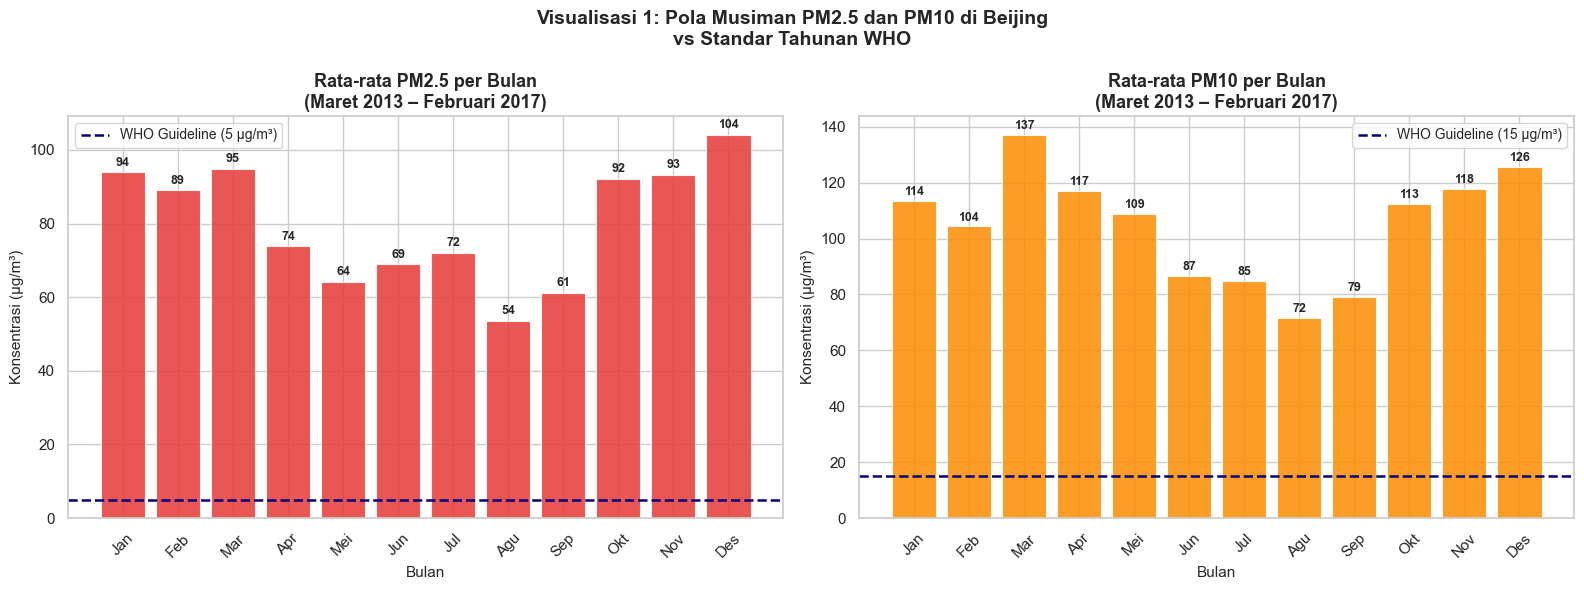

In [12]:
sns.set_theme(style='whitegrid')
COLORS = {'PM2.5': '#E53935', 'PM10': '#FB8C00'}
month_order = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']

seasonal_vals = df.groupby('month')[['PM2.5', 'PM10']].mean()
seasonal_vals.index = month_order

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, pollutant, who_val in zip(axes, ['PM2.5', 'PM10'], [5, 15]):
    bars = ax.bar(month_order, seasonal_vals[pollutant],
                  color=COLORS[pollutant], alpha=0.85, edgecolor='white', linewidth=0.8)
    ax.axhline(y=who_val, color='navy', linestyle='--', linewidth=1.8,
               label=f'WHO Guideline ({who_val} μg/m³)')
    ax.set_title(f'Rata-rata {pollutant} per Bulan\n(Maret 2013 – Februari 2017)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Bulan', fontsize=11)
    ax.set_ylabel('Konsentrasi (μg/m³)', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=10)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 1,
                f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Visualisasi 1: Pola Musiman PM2.5 dan PM10 di Beijing\nvs Standar Tahunan WHO',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

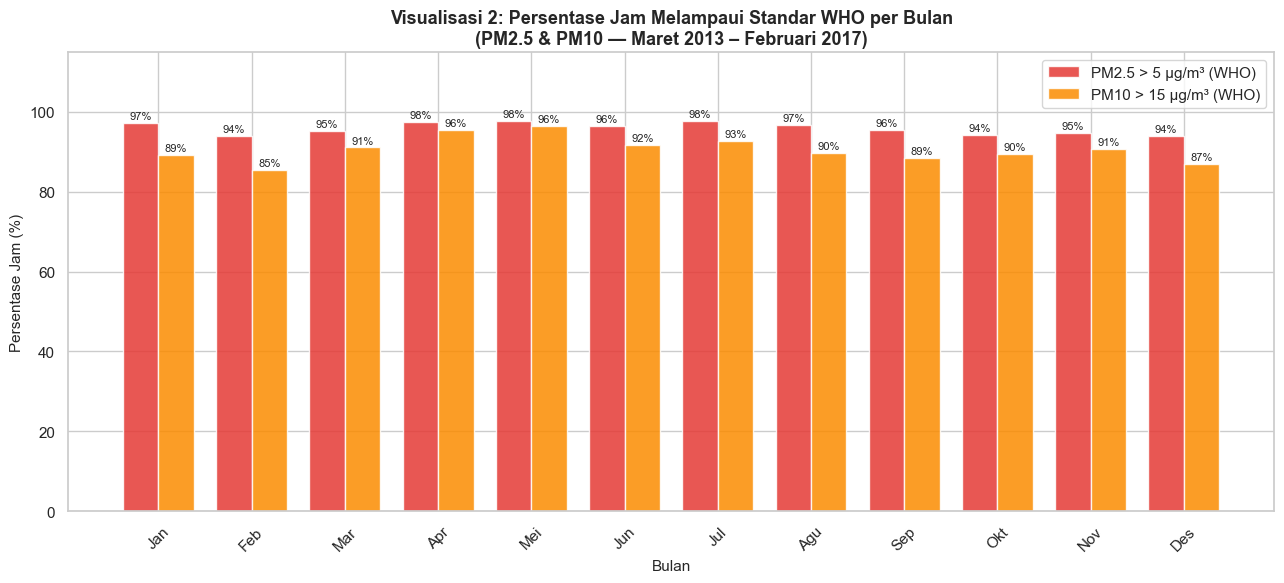

In [13]:
fig, ax = plt.subplots(figsize=(13, 6))

x       = np.arange(len(month_order))
width   = 0.38
pm25_ex = monthly_exceed_pm25.values
pm10_ex = monthly_exceed_pm10.values

bars1 = ax.bar(x - width / 2, pm25_ex, width, label='PM2.5 > 5 μg/m³ (WHO)',
               color='#E53935', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width / 2, pm10_ex, width, label='PM10 > 15 μg/m³ (WHO)',
               color='#FB8C00', alpha=0.85, edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.5,
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.5,
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8)

ax.set_title('Visualisasi 2: Persentase Jam Melampaui Standar WHO per Bulan\n'
             '(PM2.5 & PM10 — Maret 2013 – Februari 2017)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Bulan', fontsize=11)
ax.set_ylabel('Persentase Jam (%)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(month_order, rotation=45)
ax.set_ylim(0, 115)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

### Pertanyaan 2: Pengaruh Meteorologi terhadap Konsentrasi PM2.5

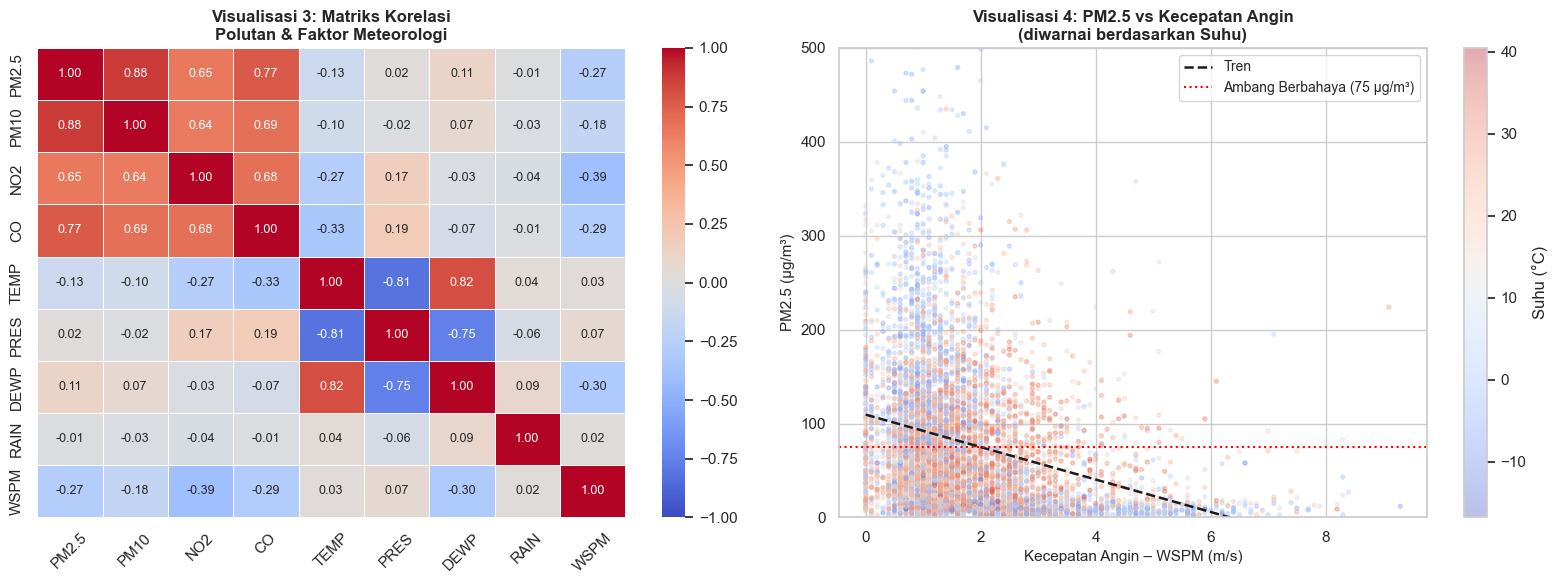

In [14]:
met_cols      = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
available_met = [c for c in met_cols if c in df.columns]
corr_vars     = ['PM2.5', 'PM10', 'NO2', 'CO'] + available_met
corr_matrix   = df[corr_vars].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1: Correlation heatmap ---
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            linewidths=0.5, annot_kws={'size': 9})
axes[0].set_title('Visualisasi 3: Matriks Korelasi\nPolutan & Faktor Meteorologi',
                  fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# --- Chart 2: Scatter PM2.5 vs WSPM colored by TEMP ---
sample = df.dropna(subset=['WSPM', 'PM2.5', 'TEMP']).sample(n=min(6000, len(df)), random_state=42)
sc = axes[1].scatter(sample['WSPM'], sample['PM2.5'],
                     c=sample['TEMP'], cmap='coolwarm', alpha=0.35, s=8)
# Trend line
z = np.polyfit(sample['WSPM'], sample['PM2.5'], 1)
x_line = np.linspace(sample['WSPM'].min(), sample['WSPM'].max(), 200)
axes[1].plot(x_line, np.poly1d(z)(x_line), 'k--', linewidth=1.8, label='Tren')
axes[1].axhline(y=75, color='red', linestyle=':', linewidth=1.5, label='Ambang Berbahaya (75 μg/m³)')
plt.colorbar(sc, ax=axes[1], label='Suhu (°C)')
axes[1].set_title('Visualisasi 4: PM2.5 vs Kecepatan Angin\n(diwarnai berdasarkan Suhu)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kecepatan Angin – WSPM (m/s)', fontsize=11)
axes[1].set_ylabel('PM2.5 (μg/m³)', fontsize=11)
axes[1].set_ylim(0, 500)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

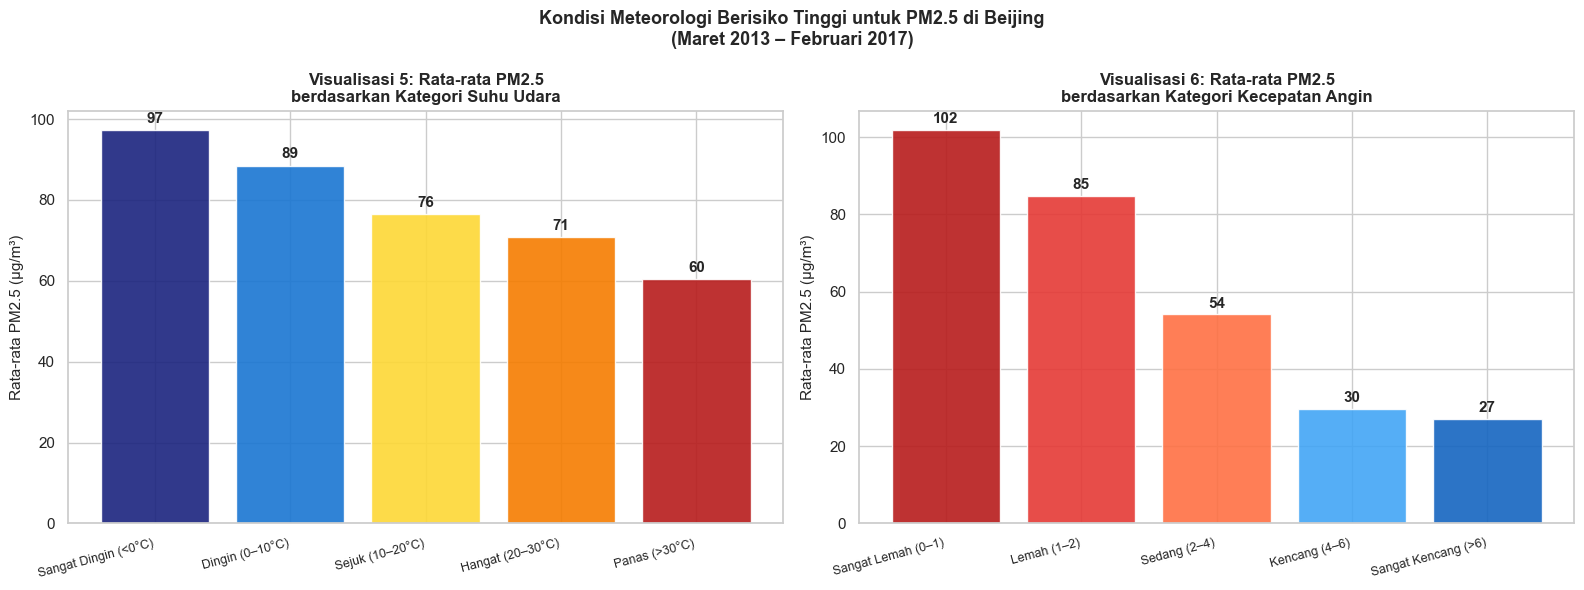

In [15]:
temp_order = ['Sangat Dingin (<0°C)', 'Dingin (0–10°C)',
              'Sejuk (10–20°C)', 'Hangat (20–30°C)', 'Panas (>30°C)']
wind_order = ['Sangat Lemah (0–1)', 'Lemah (1–2)',
              'Sedang (2–4)', 'Kencang (4–6)', 'Sangat Kencang (>6)']

temp_avg = df.groupby('TEMP_cat')['PM2.5'].mean().reindex(temp_order)
wind_avg = df.groupby('WSPM_cat')['PM2.5'].mean().reindex(wind_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart: PM2.5 by temperature category
colors_t = ['#1A237E', '#1976D2', '#FDD835', '#F57C00', '#B71C1C']
bars_t   = axes[0].bar(range(len(temp_order)), temp_avg, color=colors_t, edgecolor='white', alpha=0.9)
axes[0].set_xticks(range(len(temp_order)))
axes[0].set_xticklabels(temp_order, fontsize=9, rotation=15, ha='right')
axes[0].set_title('Visualisasi 5: Rata-rata PM2.5\nberdasarkan Kategori Suhu Udara',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Rata-rata PM2.5 (μg/m³)', fontsize=11)
for i, v in enumerate(temp_avg):
    if not np.isnan(v):
        axes[0].text(i, v + 1, f'{v:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Chart: PM2.5 by wind speed category
colors_w = ['#B71C1C', '#E53935', '#FF7043', '#42A5F5', '#1565C0']
bars_w   = axes[1].bar(range(len(wind_order)), wind_avg, color=colors_w, edgecolor='white', alpha=0.9)
axes[1].set_xticks(range(len(wind_order)))
axes[1].set_xticklabels(wind_order, fontsize=9, rotation=15, ha='right')
axes[1].set_title('Visualisasi 6: Rata-rata PM2.5\nberdasarkan Kategori Kecepatan Angin',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Rata-rata PM2.5 (μg/m³)', fontsize=11)
for i, v in enumerate(wind_avg):
    if not np.isnan(v):
        axes[1].text(i, v + 1, f'{v:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Kondisi Meteorologi Berisiko Tinggi untuk PM2.5 di Beijing\n(Maret 2013 – Februari 2017)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight – Visualisasi 1 & 2 (Pertanyaan 1):**
- Setiap bulan dalam setahun memiliki rata-rata PM2.5 dan PM10 yang **jauh melampaui standar WHO** — nilai terendah pun (Agustus: 54 μg/m³) masih 10× di atas batas PM2.5 WHO.
- PM2.5 tertinggi pada **Desember** (104 μg/m³); PM10 tertinggi pada **Maret** (137 μg/m³) karena pengaruh badai debu musim semi.
- Persentase jam melampaui WHO PM2.5 sangat tinggi sepanjang tahun (**95,9% rata-rata**), dengan bulan terparah **Mei** (97,8%) dan terbaik **Februari** (93,9%).

**Insight – Visualisasi 3 & 4 (Pertanyaan 2):**
- Korelasi PM2.5 dengan WSPM adalah **r = −0,27** dan dengan TEMP adalah **r = −0,13**, mengkonfirmasi bahwa angin lemah dan udara dingin memperparah polusi.
- Pada kecepatan angin rendah (WSPM < 1 m/s), titik data PM2.5 tinggi tersebar secara masif — terlihat dari pita padat di bagian kiri scatter plot.
- Konsentrasi berbahaya (>75 μg/m³) hampir selalu terjadi saat suhu dingin (warna biru) dan angin lemah — mengkonfirmasi pola kombinasi berisiko tinggi.

## Analisis Lanjutan: Klasifikasi & Pengelompokan Kualitas Udara (Binning & Manual Clustering)

Analisis ini menggunakan dua teknik tanpa machine learning:
1. **Binning**: Mengklasifikasikan setiap rekaman jam ke dalam kategori kualitas udara berdasarkan *breakpoints* PM2.5 standar US EPA.
2. **Manual Clustering**: Mengelompokkan 12 stasiun ke dalam tiga kluster berdasarkan rata-rata PM2.5 menggunakan kuantil.

In [16]:
# ─── BINNING: Klasifikasi PM2.5 ke Kategori Kualitas Udara (US EPA breakpoints) ───
aq_bins   = [0, 12.0, 35.4, 55.4, 150.4, 250.4, float('inf')]
aq_labels = ['Baik', 'Sedang', 'Tidak Sehat (Sensitif)', 'Tidak Sehat', 'Sangat Tidak Sehat', 'Berbahaya']
aq_colors = ['#00C853', '#FFD600', '#FF6D00', '#DD2C00', '#880E4F', '#4A0010']

df['AQ_Level'] = pd.cut(df['PM2.5'], bins=aq_bins, labels=aq_labels)

# Overall distribution
aq_dist = df['AQ_Level'].value_counts().sort_index()
aq_pct  = (aq_dist / len(df) * 100).round(2)
summary = pd.DataFrame({'Jumlah Jam': aq_dist, 'Persentase (%)': aq_pct})
print("=== Distribusi Tingkat Kualitas Udara PM2.5 (Maret 2013 – Februari 2017) ===")
print(summary)

# Distribution by month
monthly_aq = df.groupby('month')['AQ_Level'].value_counts(normalize=True).unstack(fill_value=0) * 100
monthly_aq.index = [month_names[m] for m in monthly_aq.index]
print("\n=== Distribusi Kualitas Udara per Bulan (%) ===")
print(monthly_aq[aq_labels].round(1))

=== Distribusi Tingkat Kualitas Udara PM2.5 (Maret 2013 – Februari 2017) ===
                        Jumlah Jam  Persentase (%)
AQ_Level                                          
Baik                         63920           15.26
Sedang                       92339           22.05
Tidak Sehat (Sensitif)       54076           12.91
Tidak Sehat                 144630           34.53
Sangat Tidak Sehat           44836           10.70
Berbahaya                    19035            4.54

=== Distribusi Kualitas Udara per Bulan (%) ===
AQ_Level  Baik  Sedang  Tidak Sehat (Sensitif)  Tidak Sehat  \
Jan      18.80   21.20                    7.60        30.90   
Feb      24.90   20.80                    7.70        25.00   
Mar      17.00   17.00                    9.00        34.60   
Apr      10.90   18.50                   15.70        44.20   
Mei       9.20   25.20                   19.90        39.20   
Jun      11.30   24.00                   16.90        38.30   
Jul       8.10   23.00   

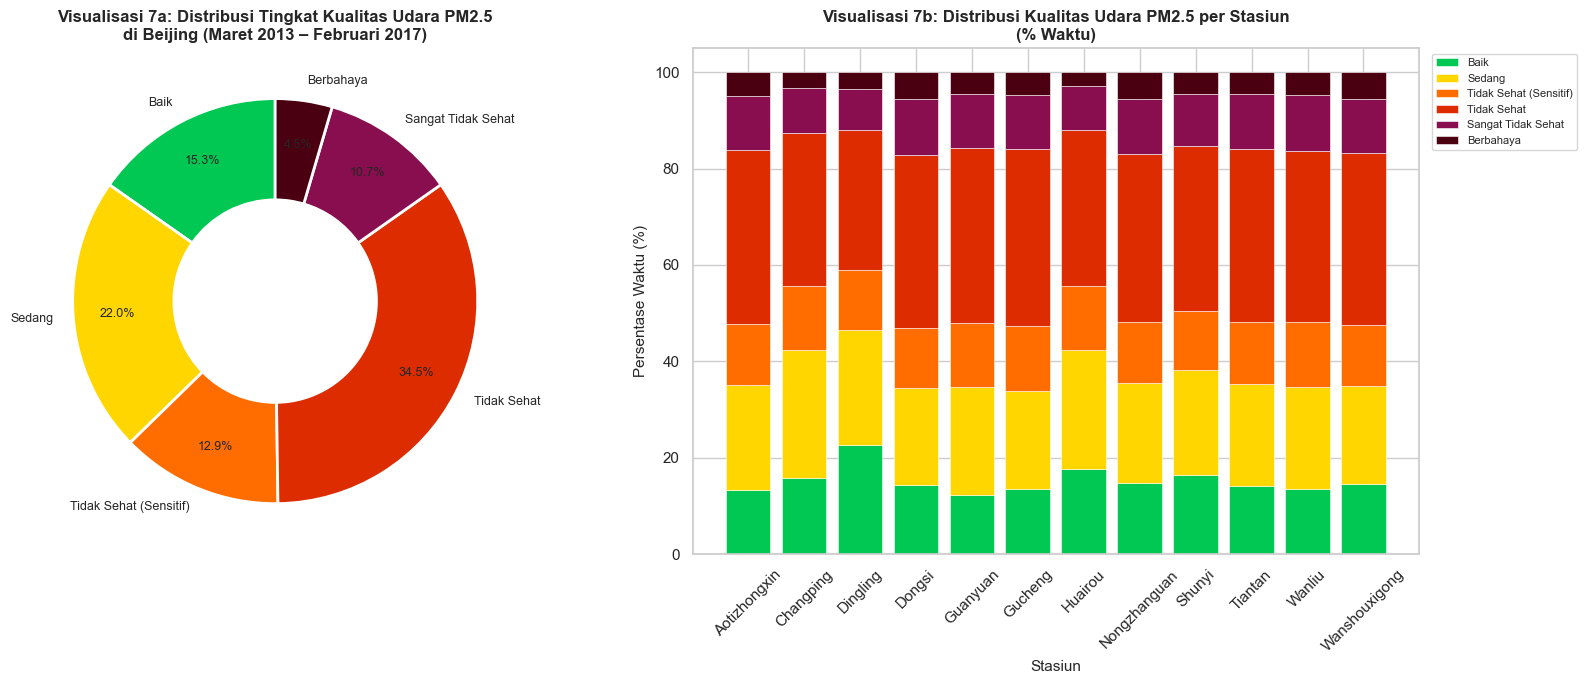

In [17]:
# Distribution of AQ levels (all data)
aq_dist_clean = df['AQ_Level'].value_counts().sort_index()
present_labels = [l for l in aq_labels if l in aq_dist_clean.index]
present_colors = [aq_colors[aq_labels.index(l)] for l in present_labels]

# Distribution by station
station_aq     = df.groupby(['station', 'AQ_Level']).size().unstack(fill_value=0)
station_aq_pct = station_aq.div(station_aq.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# --- Donut chart: overall distribution ---
wedge_props = {'width': 0.5, 'edgecolor': 'white', 'linewidth': 2}
axes[0].pie(
    aq_dist_clean[present_labels],
    labels=present_labels,
    autopct='%1.1f%%',
    colors=present_colors,
    wedgeprops=wedge_props,
    startangle=90,
    pctdistance=0.78,
    textprops={'fontsize': 9},
)
axes[0].set_title('Visualisasi 7a: Distribusi Tingkat Kualitas Udara PM2.5\ndi Beijing (Maret 2013 – Februari 2017)',
                  fontsize=12, fontweight='bold')

# --- Stacked bar: per station ---
bottom = np.zeros(len(station_aq_pct))
for label, color in zip(aq_labels, aq_colors):
    if label in station_aq_pct.columns:
        vals = station_aq_pct[label].values
        axes[1].bar(station_aq_pct.index, vals, bottom=bottom,
                    label=label, color=color, edgecolor='white', linewidth=0.4)
        bottom += vals

axes[1].set_title('Visualisasi 7b: Distribusi Kualitas Udara PM2.5 per Stasiun\n(% Waktu)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Stasiun', fontsize=11)
axes[1].set_ylabel('Persentase Waktu (%)', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='upper left', fontsize=8, bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

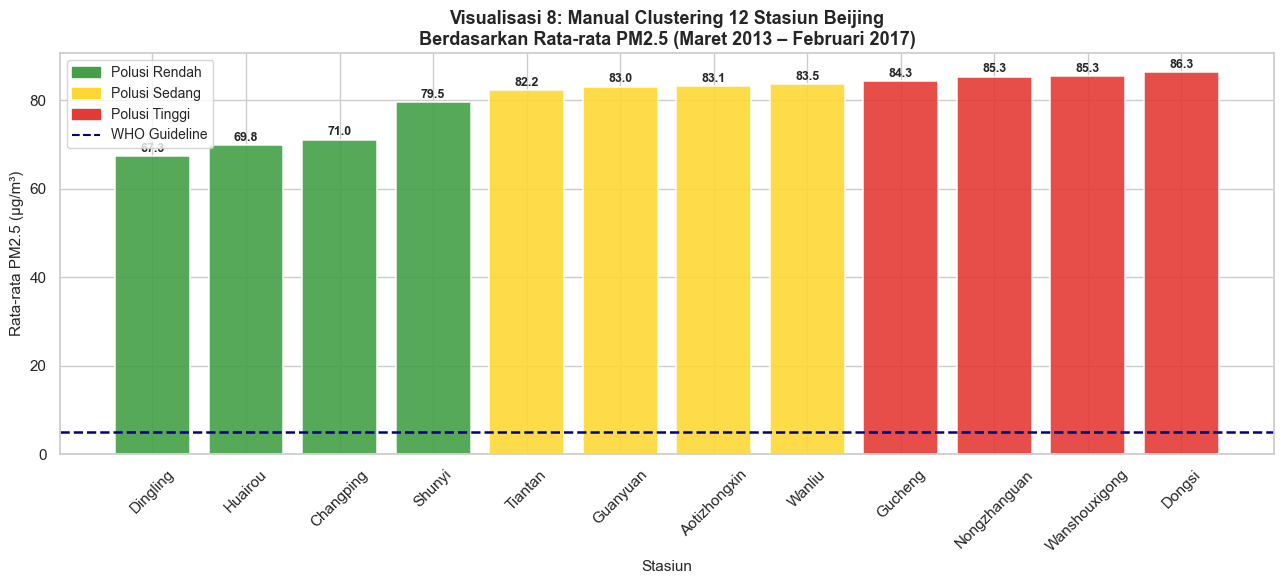


=== Hasil Pengelompokan Stasiun ===
               Rata-rata PM2.5        Kluster
station                                      
Dingling                 67.32  Polusi Rendah
Huairou                  69.81  Polusi Rendah
Changping                71.01  Polusi Rendah
Shunyi                   79.46  Polusi Rendah
Tiantan                  82.24  Polusi Sedang
Guanyuan                 83.02  Polusi Sedang
Aotizhongxin             83.15  Polusi Sedang
Wanliu                   83.51  Polusi Sedang
Gucheng                  84.30  Polusi Tinggi
Nongzhanguan             85.27  Polusi Tinggi
Wanshouxigong            85.33  Polusi Tinggi
Dongsi                   86.27  Polusi Tinggi


In [18]:
# ─── Station rankings with cluster color coding ───
pm25_station = df.groupby('station')['PM2.5'].mean().sort_values()
q33 = pm25_station.quantile(0.33)
q67 = pm25_station.quantile(0.67)
station_cluster = pd.cut(pm25_station,
    bins=[0, q33, q67, float('inf')],
    labels=['Polusi Rendah', 'Polusi Sedang', 'Polusi Tinggi'])

cluster_color_map = {'Polusi Rendah': '#43A047', 'Polusi Sedang': '#FDD835', 'Polusi Tinggi': '#E53935'}
bar_colors = [cluster_color_map[c] for c in station_cluster.values]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(pm25_station.index, pm25_station.values, color=bar_colors,
              edgecolor='white', linewidth=1.2, alpha=0.9)
ax.axhline(y=5, color='navy', linestyle='--', linewidth=1.8, label='WHO Guideline (5 μg/m³)')

for bar, val in zip(bars, pm25_station.values):
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

legend_handles = [mpatches.Patch(color=v, label=k) for k, v in cluster_color_map.items()]
legend_handles.append(plt.Line2D([0], [0], color='navy', linestyle='--', label='WHO Guideline'))
ax.legend(handles=legend_handles, fontsize=10)
ax.set_title('Visualisasi 8: Manual Clustering 12 Stasiun Beijing\nBerdasarkan Rata-rata PM2.5 (Maret 2013 – Februari 2017)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Stasiun', fontsize=11)
ax.set_ylabel('Rata-rata PM2.5 (μg/m³)', fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print("\n=== Hasil Pengelompokan Stasiun ===")
cluster_result = pd.DataFrame({'Rata-rata PM2.5': pm25_station.round(2), 'Kluster': station_cluster})
print(cluster_result.sort_values('Rata-rata PM2.5').to_string())

**Insight – Binning Kualitas Udara:**
- Kategori **"Tidak Sehat"** mendominasi distribusi dengan **34,5%** waktu, diikuti "Sedang" (22,1%) dan "Baik" (15,3%). Secara keseluruhan, **49,8% jam** di Beijing tergolong "Tidak Sehat" atau lebih buruk.
- Bulan-bulan musim dingin mencatat proporsi kategori "Berbahaya" tertinggi: **Desember (11,6%)** dan **Oktober (8,7%)**, sedangkan Agustus hampir bebas dari kategori Berbahaya (0,1%).

**Insight – Manual Clustering Stasiun:**
- **Polusi Rendah** (PM2.5: 67–79 μg/m³): Dingling (67,3), Huairou (69,8), Changping (71,0), Shunyi (79,5) — stasiun pinggiran/suburban dengan ventilasi lebih baik.
- **Polusi Sedang** (PM2.5: 82–84 μg/m³): Tiantan (82,2), Guanyuan (83,0), Aotizhongxin (83,2), Wanliu (83,5).
- **Polusi Tinggi** (PM2.5: 84–86 μg/m³): Gucheng (84,3), Nongzhanguan (85,3), Wanshouxigong (85,3), Dongsi (86,3) — stasiun urban padat yang membutuhkan intervensi prioritas.

## Conclusion & Recommendation

- **Kesimpulan Pertanyaan 1:** Selama periode Maret 2013 – Februari 2017, rata-rata PM2.5 tertinggi terjadi pada bulan **Desember** (104 μg/m³, **20× di atas batas WHO**), sedangkan PM10 tertinggi pada **Maret** (137 μg/m³, **9× di atas batas WHO**) — dipengaruhi badai debu musim semi. Sebanyak **95,9% jam PM2.5** dan **90,7% jam PM10** melampaui standar WHO; bahkan bulan terbaik (Agustus) pun masih mencatat PM2.5 ≈ 54 μg/m³ (10× di atas batas).

- **Kesimpulan Pertanyaan 2:** Kecepatan angin (r = **−0,27**) dan suhu udara (r = **−0,13**) berkorelasi negatif dengan PM2.5. Rata-rata PM2.5 pada kondisi "Sangat Dingin" (<0°C) mencapai **97 μg/m³** vs **60 μg/m³** pada kondisi "Panas" (>30°C) — sekitar **1,6× lebih tinggi**. Sebanyak **163.941 jam (39,1%)** tercatat sebagai kondisi berbahaya (PM2.5 > 75 μg/m³), dengan karakteristik WSPM dan suhu rata-rata lebih rendah dibanding kondisi normal.

- **Kesimpulan Analisis Lanjutan:** Binning menunjukkan **49,8% jam** di Beijing masuk kategori "Tidak Sehat" atau lebih buruk, dengan puncak kategori "Berbahaya" pada **Desember (11,6%)**. Clustering manual mengidentifikasi 4 stasiun kluster "Polusi Tinggi" (Gucheng, Nongzhanguan, Wanshouxigong, Dongsi) dan 4 stasiun "Polusi Rendah" (Dingling, Huairou, Changping, Shunyi), memberikan peta prioritas intervensi yang terukur berbasis lokasi.

**Rekomendasi Action Item:**

1. **Sistem Peringatan Dini Berbasis Meteorologi:** Kembangkan model peringatan dini yang memantau suhu dan kecepatan angin secara real-time. Aktifkan level siaga saat TEMP < 5°C **DAN** WSPM < 1 m/s untuk mengurangi paparan masyarakat di luar ruangan.

2. **Regulasi Emisi Musiman:** Perketat kebijakan emisi sektoral (transportasi, industri, pemanas rumah tangga) selama periode Oktober–Februari, mengingat bulan-bulan ini secara konsisten mencatat tingkat polusi tertinggi.

3. **Intervensi Prioritas Berbasis Lokasi:** Fokuskan program pengendalian pencemaran di stasiun berkluster "Polusi Tinggi" (Dongsi, Gucheng) dengan audit emisi sumber lokal dan penambahan ruang hijau penyerap polutan.

4. **Program Kesehatan Masyarakat:** Distribusikan masker N95 dan panduan aktivitas fisik luar ruangan berbasis kategori AQ (terutama kategori "Tidak Sehat" ke atas) kepada kelompok rentan (anak-anak, lansia) di seluruh 12 stasiun selama musim dingin.